# Section 2 — Risk decomposition

*How much of the index's volatility does each basket cause, relative to the money in it, and how much does the answer depend on the covariance estimator?*

The same decomposition is run under three covariance estimators that differ only in how far back they look: the full sample (April 2019 to September 2026, every day weighted equally), the trailing 252 days, and an exponentially weighted estimate with $\lambda = 0.94$, whose half-life is about 11 trading days. Capital weights are the current ones throughout.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quiet_index import config as cfg
from quiet_index import data, pipeline, plots

pd.set_option("display.width", 200)
study_data = data.load_study_data() #cached prices, returns and index weights, cut off at the study end date

section_1 = pipeline.run_section_1(study_data)
section_2 = pipeline.run_section_2(study_data, section_1)
tables = section_2["tables"]

## 2.1 Capital weight vector $w$

Each basket's share of current index weight, normalized to sum to 1.

In [2]:
index_weights_vector = section_2["index_weights_vector"]
index_weights_vector.round(4)

basket
M7              0.4664
AI_HI_MOM_HI    0.2336
AI_HI_MOM_LO    0.0874
AI_LO_MOM_HI    0.0745
AI_LO_MOM_LO    0.1381
Name: weight, dtype: float64

## 2.2 Index volatility under the three estimators

$\Sigma = D\,R\,D$, with $D$ the diagonal matrix of annualized basket volatilities and $R$ the correlation matrix, and $\sigma_p = \sqrt{w^\top \Sigma\, w}$. The 10-day 99% VaR and ES are the parametric-normal figures with the mean set to zero.

In [3]:
(tables["s2_index_risk"] * 100).round(1) #annualized volatility, 10-day 99% VaR and ES, all in percent

,index_volatility,var_99_10d,es_99_10d
estimator,,,
Full sample,24.1,-11.2,-12.8
Trailing 252d,15.6,-7.2,-8.3
EWMA 0.94,11.6,-5.4,-6.2


Trailing 252d: today 15.6%, lower than on 91% of days since 2020-03-31
EWMA 0.94: today 11.6%, lower than on 97% of days since 2020-03-31


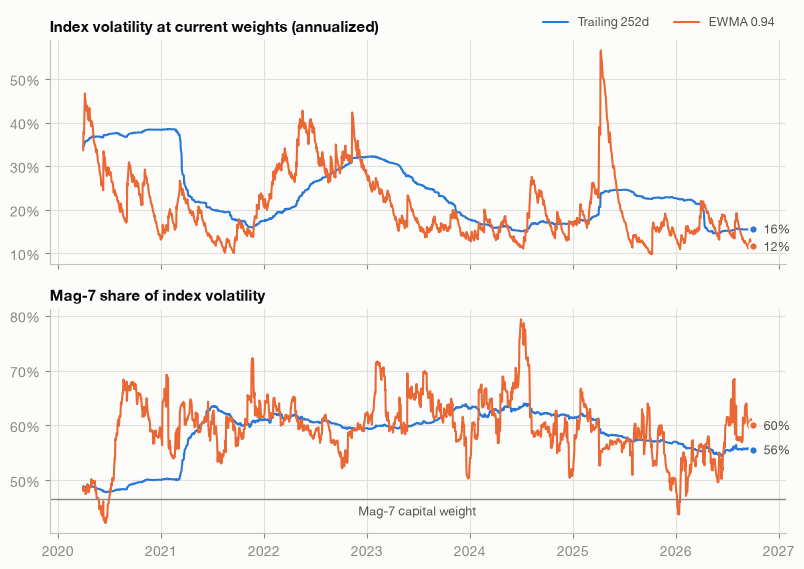

In [4]:
risk_through_time = tables["s2_risk_through_time"]
risk_through_time.attrs["m7_weight"] = index_weights_vector["M7"]
for estimator_name in ["Trailing 252d", "EWMA 0.94"]:
    volatility = risk_through_time[f"{estimator_name} volatility"]
    print(f"{estimator_name}: today {volatility.iloc[-1]:.1%}, lower than on {(volatility > volatility.iloc[-1]).mean():.0%} of days since {volatility.index[0].date()}")

plots.plot_risk_through_time(risk_through_time);

The same portfolio on the same day has an annualized volatility of 24.1%, 15.6% or 11.6% depending on the estimator, and a 10-day 99% VaR of 11.2%, 7.2% or 5.4%. The full-sample figure is about twice the EWMA figure. Nothing about the portfolio differs between the three rows. The whole of the difference comes from how much history each estimator is allowed to remember: the full sample still contains March 2020, the 2022 drawdown and April 2025, the trailing year contains none of those, and the EWMA estimate is effectively a statement about the last two to three months.

The chart puts the current readings in context by running today's weights through each day's covariance estimate. The trailing-year volatility of 15.6% is lower than on 91% of days since March 2020, and the EWMA volatility of 11.6% is lower than on 97% of days. Both short-memory estimators are therefore reporting a level of risk close to the bottom of what they have reported over the past six years, which is the sense in which the index is currently quiet.

## 2.3 Risk decomposition

| Metric | Formula | Reads as |
|---|---|---|
| Marginal contribution (MCR) | $(\Sigma w)_i / \sigma_p$ | Change in $\sigma_p$ per unit of extra weight in basket $i$ |
| Component risk | $w_i \cdot \mathrm{MCR}_i$ | Basket $i$'s slice of $\sigma_p$, in volatility points; sums to $\sigma_p$ (Euler) |
| Risk share | $\mathrm{CR}_i / \sigma_p$ | Basket $i$'s fraction of total risk; sums to 1 |

Risk share exceeds capital weight exactly when $\mathrm{MCR}_i > \sigma_p$.

In [5]:
risk_decomposition = tables["s2_risk_decomposition"]
component_totals = risk_decomposition["component_risk"].groupby("estimator", sort=False).sum()
assert np.allclose(component_totals, tables["s2_index_risk"]["index_volatility"]) #Euler check: components add up to index volatility under every estimator

risk_decomposition.round(4)

weight  marginal_contribution_risk  component_risk  risk_share  risk_share_to_weight
estimator     basket                                                                                            
Full sample   M7            0.4664                      0.2901          0.1353      0.5618                1.2047
              AI_HI_MOM_HI  0.2336                      0.2624          0.0613      0.2546                1.0896
              AI_HI_MOM_LO  0.0874                      0.2272          0.0199      0.0824                0.9434
              AI_LO_MOM_HI  0.0745                      0.1182          0.0088      0.0365                0.4906
              AI_LO_MOM_LO  0.1381                      0.1127          0.0156      0.0646                0.4680
Trailing 252d M7            0.4664                      0.1862          0.0868      0.5558                1.1918
              AI_HI_MOM_HI  0.2336                      0.2242          0.0524      0.3353                1.4350
              AI_HI_MOM_LO  0.0874                      0.1509          0.0132      0.0844                0.9658
              AI_LO_MOM_HI  0.0745                      0.0094          0.0007      0.0045                0.0599
              AI_LO_MOM_LO  0.1381                      0.0227          0.0031      0.0201                0.1453
EWMA 0.94     M7            0.4664                      0.1494          0.0697      0.6001                1.2868
              AI_HI_MOM_HI  0.2336                      0.1443          0.0337      0.2904                1.2430
              AI_HI_MOM_LO  0.0874                      0.0645          0.0056      0.0485                0.5553
              AI_LO_MOM_HI  0.0745                      0.0305          0.0023      0.0196                0.2629
              AI_LO_MOM_LO  0.1381                      0.0348          0.0048      0.0414                0.2994

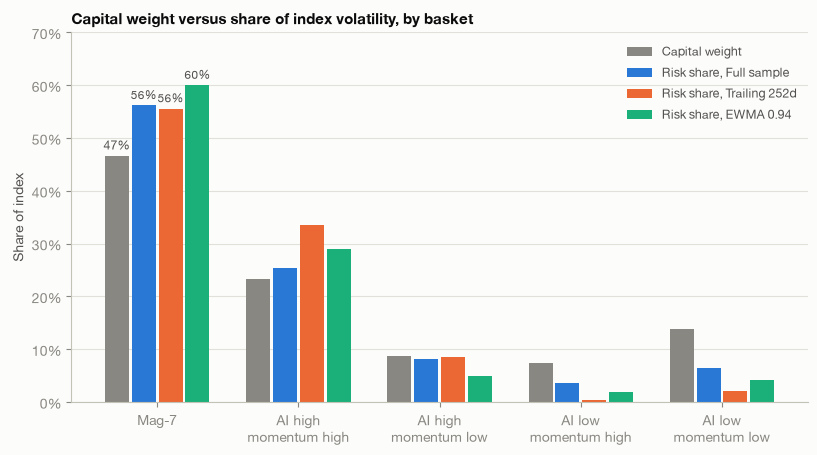

In [6]:
plots.plot_weight_vs_risk_share(risk_decomposition);

The Mag-7 holds 46.6% of the capital and is responsible for 56.2%, 55.6% and 60.0% of index volatility under the three estimators. Its risk share is between 1.19 and 1.29 times its weight whichever lookback is used, and the history in the chart above shows the same thing through time: on the trailing-year estimate the Mag-7's risk share has been above its capital weight on every day since March 2020, ranging between 48% and 64%. This is the most stable result in the study.

The AI-high, momentum-high basket also carries more risk than capital under all three estimators, but here the size of the excess depends heavily on the lookback. It holds 23.4% of capital and 25.5% of risk on the full sample, 33.5% on the trailing year and 29.0% on the EWMA estimate. On the trailing year its marginal contribution (22.4%) is higher than the Mag-7's (18.6%), which means that over the past twelve months an extra dollar in this basket added more to index volatility than an extra dollar in the Mag-7.

The two AI-low baskets together hold 21.3% of capital. They account for 10.1% of risk on the full sample, 6.1% on the EWMA estimate and only 2.5% on the trailing year. Over the past year these 46 names have had marginal contributions of 0.9% and 2.3% against an index volatility of 15.6%, so they have been close to uncorrelated with whatever has been moving the index.

## 2.4 VaR and ES sensitivities

At 99%, $\partial \mathrm{VaR}/\partial w_i = \mu_i + z\cdot\mathrm{MCR}_i$ with $z = \Phi^{-1}(0.01) \approx -2.326$, and $\partial \mathrm{ES}/\partial w_i = \mu_i - [\varphi(z)/0.01]\cdot\mathrm{MCR}_i$, where the coefficient is about 2.665. The table sets $\mu = 0$ and scales to a 10-day horizon.

In [7]:
(tables["s2_var_es_sensitivities"] * 100).round(2) #change in the 10-day 99% VaR and ES, in percent, per unit of extra weight in each basket

var_sensitivity  es_sensitivity
estimator     basket                                       
Full sample   M7                     -13.44          -15.40
              AI_HI_MOM_HI           -12.16          -13.93
              AI_HI_MOM_LO           -10.53          -12.06
              AI_LO_MOM_HI            -5.48           -6.27
              AI_LO_MOM_LO            -5.22           -5.98
Trailing 252d M7                      -8.63           -9.89
              AI_HI_MOM_HI           -10.39          -11.90
              AI_HI_MOM_LO            -6.99           -8.01
              AI_LO_MOM_HI            -0.43           -0.50
              AI_LO_MOM_LO            -1.05           -1.21
EWMA 0.94     M7                      -6.92           -7.93
              AI_HI_MOM_HI            -6.69           -7.66
              AI_HI_MOM_LO            -2.99           -3.42
              AI_LO_MOM_HI            -1.41           -1.62
              AI_LO_MOM_LO            -1.61           -1.85

Every sensitivity is negative, which says that adding to any basket from outside the portfolio makes the loss quantile worse. That is what one would expect of five long positions that are all positively correlated with each other. The useful information is in the differences between rows. On the trailing-year estimate, moving one percent of the index out of the AI-low, momentum-high basket (sensitivity −0.43%) and into the AI-high, momentum-high basket (−10.39%) would deepen the 10-day 99% VaR by about 0.10 percentage points of portfolio value. Moving the same one percent between the two AI-low baskets would change it by less than 0.01.

The ES sensitivities are the VaR sensitivities multiplied by a constant (2.665 / 2.326 = 1.146), because both are built from the same marginal contribution and differ only in the tail coefficient applied to it. Under the normal assumption ES therefore ranks the baskets identically to VaR and adds no information about which basket matters most.

## 2.5 AI split against momentum split

*Which of the two sorting variables explains more of the dispersion in risk contributions?*

Two views. The first groups the four baskets outside the Mag-7 along each axis and compares risk share per unit of capital. The second works at the level of individual stocks and is forward-looking: each stock's AI loading and momentum at a formation date are compared with its marginal contribution to index risk over the *following* quarter.

In [8]:
tables["s2_split_comparison"].round(3)

weight  risk_share  risk_share_to_weight
estimator     group                                                  
Full sample   AI high         0.321       0.337                 1.050
              AI low          0.213       0.101                 0.476
              Momentum high   0.308       0.291                 0.945
              Momentum low    0.226       0.147                 0.652
Trailing 252d AI high         0.321       0.420                 1.307
              AI low          0.213       0.025                 0.115
              Momentum high   0.308       0.340                 1.103
              Momentum low    0.226       0.104                 0.463
EWMA 0.94     AI high         0.321       0.339                 1.056
              AI low          0.213       0.061                 0.287
              Momentum high   0.308       0.310                 1.006
              Momentum low    0.226       0.090                 0.399

In [9]:
sorting_power = tables["s2_sorting_variable_power"]
lambda_wins = (sorting_power["ai_beta_rank_corr"].abs() > sorting_power["momentum_rank_corr"].abs()).sum()
print(f"AI loading has the higher rank correlation with next-quarter marginal contribution in {lambda_wins} of {len(sorting_power)} quarters")
sorting_power.drop(columns="names").mean().round(2).to_frame("average across quarters")

AI loading has the higher rank correlation with next-quarter marginal contribution in 28 of 30 quarters


,average across quarters
ai_beta_rank_corr,0.69
ai_beta_split_r2,0.33
momentum_rank_corr,0.17
momentum_split_r2,0.14
beta_mkt_rank_corr,0.77
beta_mkt_split_r2,0.40


At the basket level the AI split produces the wider separation under every estimator. On the full sample the AI-high half carries 1.05 times its weight in risk and the AI-low half 0.48 times, a ratio of about 2.2 to 1. The momentum-high and momentum-low halves carry 0.95 and 0.65 times, a ratio of about 1.4 to 1. On the trailing year the AI gap widens to 1.31 against 0.12, and the momentum gap to 1.10 against 0.46.

The stock-level test agrees and is the cleaner evidence, because the sorting variable is measured before the risk contribution it is compared with. A stock's AI loading at a formation date has an average rank correlation of 0.69 with its marginal contribution to index risk over the next quarter. Momentum has 0.17. The AI loading is the better of the two in 28 of the 30 quarters, and a simple high/low split on it explains 33% of the cross-sectional dispersion in marginal contributions against 14% for momentum.

Plain market beta does better than either, with a rank correlation of 0.77 and 40% of dispersion explained. That is to be expected, since a stock's marginal contribution to a cap-weighted index is close to its beta against that index. The fair summary is that AI loading explains considerably more of the dispersion in risk contributions than momentum does, that it does so partly because high-loading stocks are also high-beta stocks, and that momentum adds little once the AI sort is in place.

## Conclusions

Capital weight understates how concentrated the index's risk is. The Mag-7 holds 47% of the money and between 56% and 60% of the volatility, and that result holds under all three estimators and on every day of the history examined. Adding the AI-high, momentum-high basket brings the total to 70% of capital and between 82% and 89% of volatility.

Which conclusions are stable across lookbacks, and which are not, is the main finding of this section. The ordering of the baskets by risk share per unit of weight is stable: the Mag-7 and the AI-high, momentum-high basket are above 1 in every case and the two AI-low baskets are below 0.5 in every case. The Mag-7's ratio is stable in size as well, between 1.19 and 1.29. The level of index risk is not stable at all, ranging from 11.6% to 24.1%, and neither is the split of the remainder between the AI-high and AI-low baskets, where the AI-low share ranges from 2.5% to 10.1%.

For anyone reading a current risk report on this index, the implication is that the *shape* of the decomposition can be trusted a good deal more than its *level*. A point-in-time volatility or VaR figure built on a one-year or shorter lookback is conditioned on a period that both short-memory estimators place near the bottom of their six-year range. Section 4 examines what happened to estimates of this kind when earlier calm periods ended.